<a href="https://colab.research.google.com/github/SANGRAMLEMBE/MTech/blob/main/Deep_Neural_Network/Practical/assignment/04_cnn_architecture_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4: CNN Architecture Experiments 🔬

**Course:** 21CSE558T - Deep Neural Network Architectures  
**Module 4:** CNNs - Practical Session  
**Type:** HOMEWORK ASSIGNMENT  
**Due:** Before Monday, November 3, 2025 class  
**Submission:** Upload completed notebook to Google Colab/Classroom

---

## 🎯 Learning Objectives

By completing this assignment, you will:

1. ✅ Understand how different hyperparameters affect CNN performance
2. ✅ Experiment systematically with architecture changes
3. ✅ Analyze trade-offs: accuracy vs. speed vs. parameters
4. ✅ Develop intuition for CNN design
5. ✅ Document your findings scientifically

---

## 📋 Assignment Structure

You will complete **5 experiments**:

1. **Experiment 1:** Effect of number of filters
2. **Experiment 2:** Effect of kernel size
3. **Experiment 3:** Effect of depth (number of layers)
4. **Experiment 4:** Effect of pooling strategies
5. **Experiment 5:** Your own custom architecture

**For each experiment:**
- Build and train the model
- Record accuracy, parameters, training time
- Answer reflection questions

---

## 🚀 Setup

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, AveragePooling2D,
    Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
import time
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

✅ TensorFlow version: 2.19.0
✅ GPU available: True


## Load and Prepare Data

In [2]:
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Preprocessing
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"✅ Data loaded and preprocessed")
print(f"Training samples: {x_train.shape[0]:,}")
print(f"Test samples: {x_test.shape[0]:,}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Data loaded and preprocessed
Training samples: 60,000
Test samples: 10,000


## Helper Function: Train and Evaluate

In [3]:
def train_and_evaluate(model, model_name, epochs=5, verbose=0):
    """
    Train model and return metrics
    """
    # Compile
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train
    start_time = time.time()
    history = model.fit(x_train, y_train_cat,
                       batch_size=128,
                       epochs=epochs,
                       validation_split=0.1,
                       verbose=verbose)
    training_time = time.time() - start_time

    # Evaluate
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    # Get parameters
    total_params = model.count_params()

    return {
        'name': model_name,
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'parameters': total_params,
        'training_time': training_time,
        'history': history
    }

# Results storage
results = []

print("✅ Helper function defined")

✅ Helper function defined


---

## Experiment 1: Effect of Number of Filters 🔢

**Hypothesis:** More filters → Better accuracy (but more parameters)

**Test:** Try 16, 32, 64, 128 filters in first conv layer

In [4]:
print("🧪 Experiment 1: Number of Filters\n" + "="*50)

filter_counts = [16, 32, 64, 128]

for num_filters in filter_counts:
    print(f"\nTraining with {num_filters} filters...")

    model = Sequential([
        Conv2D(num_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(num_filters*2, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ], name=f'CNN_{num_filters}_filters')

    result = train_and_evaluate(model, f'{num_filters} filters', epochs=5)
    results.append(result)

    print(f"  Accuracy: {result['test_accuracy']:.2%}")
    print(f"  Parameters: {result['parameters']:,}")
    print(f"  Time: {result['training_time']:.1f}s")

print("\n✅ Experiment 1 Complete!")

🧪 Experiment 1: Number of Filters

Training with 16 filters...
  Accuracy: 88.34%
  Parameters: 108,618
  Time: 14.0s

Training with 32 filters...
  Accuracy: 89.63%
  Parameters: 225,034
  Time: 14.0s

Training with 64 filters...
  Accuracy: 90.21%
  Parameters: 485,514
  Time: 20.2s

Training with 128 filters...
  Accuracy: 90.63%
  Parameters: 1,117,066
  Time: 31.3s

✅ Experiment 1 Complete!


### 📝 Reflection Questions (Experiment 1)

**Answer these in the markdown cell below:**

1. Which configuration gave the best accuracy?
2. How does parameter count change with more filters?
3. Is there a point where more filters don't help?
4. What's the trade-off between accuracy and training time?

### ✍️ YOUR ANSWERS HERE:

1. Best accuracy: [Write your answer]

2. Parameter count: [Write your answer]

3. Diminishing returns: [Write your answer]

4. Trade-offs: [Write your answer]

---

## Experiment 2: Effect of Kernel Size 📏

**Hypothesis:** Larger kernels → Larger receptive field but more parameters

**Test:** Try kernel sizes 3×3, 5×5, 7×7

In [5]:
print("🧪 Experiment 2: Kernel Size\n" + "="*50)

kernel_sizes = [3, 5, 7]

for k_size in kernel_sizes:
    print(f"\nTraining with {k_size}×{k_size} kernels...")

    model = Sequential([
        Conv2D(32, (k_size, k_size), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (k_size, k_size), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ], name=f'CNN_kernel_{k_size}x{k_size}')

    result = train_and_evaluate(model, f'{k_size}×{k_size} kernel', epochs=5)
    results.append(result)

    print(f"  Accuracy: {result['test_accuracy']:.2%}")
    print(f"  Parameters: {result['parameters']:,}")
    print(f"  Time: {result['training_time']:.1f}s")

print("\n✅ Experiment 2 Complete!")

🧪 Experiment 2: Kernel Size

Training with 3×3 kernels...
  Accuracy: 89.71%
  Parameters: 225,034
  Time: 13.3s

Training with 5×5 kernels...
  Accuracy: 90.06%
  Parameters: 184,586
  Time: 13.8s

Training with 7×7 kernels...
  Accuracy: 88.64%
  Parameters: 136,202
  Time: 14.8s

✅ Experiment 2 Complete!


### 📝 Reflection Questions (Experiment 2)

1. Which kernel size performed best?
2. Why might larger kernels not always be better?
3. How does output size change with kernel size?
4. Modern CNNs mostly use 3×3 kernels. Based on your results, why?

### ✍️ YOUR ANSWERS HERE:

1. Best kernel size: [Write your answer]

2. Why not larger: [Write your answer]

3. Output size impact: [Write your answer]

4. Why 3×3 is popular: [Write your answer]

---

## Experiment 3: Effect of Network Depth 🏗️

**Hypothesis:** Deeper networks → Better accuracy (hierarchical features)

**Test:** Try 2, 3, 4 convolutional blocks

In [6]:
print("🧪 Experiment 3: Network Depth\n" + "="*50)

# 2 Conv blocks (baseline)
print("\nTraining with 2 conv blocks...")
model_2blocks = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name='CNN_2blocks')

result = train_and_evaluate(model_2blocks, '2 Conv Blocks', epochs=5)
results.append(result)
print(f"  Accuracy: {result['test_accuracy']:.2%}")
print(f"  Parameters: {result['parameters']:,}")

# 3 Conv blocks
print("\nTraining with 3 conv blocks...")
model_3blocks = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name='CNN_3blocks')

result = train_and_evaluate(model_3blocks, '3 Conv Blocks', epochs=5)
results.append(result)
print(f"  Accuracy: {result['test_accuracy']:.2%}")
print(f"  Parameters: {result['parameters']:,}")

# 4 Conv blocks
print("\nTraining with 4 conv blocks...")
model_4blocks = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name='CNN_4blocks')

result = train_and_evaluate(model_4blocks, '4 Conv Blocks', epochs=5)
results.append(result)
print(f"  Accuracy: {result['test_accuracy']:.2%}")
print(f"  Parameters: {result['parameters']:,}")

print("\n✅ Experiment 3 Complete!")

🧪 Experiment 3: Network Depth

Training with 2 conv blocks...
  Accuracy: 89.63%
  Parameters: 225,034

Training with 3 conv blocks...
  Accuracy: 90.06%
  Parameters: 241,546

Training with 4 conv blocks...
  Accuracy: 91.12%
  Parameters: 271,210

✅ Experiment 3 Complete!


### 📝 Reflection Questions (Experiment 3)

1. Does deeper always mean better?
2. What happens to training time as depth increases?
3. For Fashion-MNIST (28×28 images), what's a reasonable depth limit?
4. What problems might very deep networks face? (Hint: think about gradients)

### ✍️ YOUR ANSWERS HERE:

1. Deeper = better?: [Write your answer]

2. Training time: [Write your answer]

3. Reasonable depth: [Write your answer]

4. Deep network problems: [Write your answer]

---

## Experiment 4: Pooling Strategies 🏊

**Hypothesis:** Different pooling methods have different effects

**Test:** MaxPooling vs AveragePooling vs No Pooling

In [7]:
print("🧪 Experiment 4: Pooling Strategies\n" + "="*50)

# MaxPooling (standard)
print("\nTraining with MaxPooling...")
model_max = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name='CNN_MaxPool')

result = train_and_evaluate(model_max, 'MaxPooling', epochs=5)
results.append(result)
print(f"  Accuracy: {result['test_accuracy']:.2%}")

# AveragePooling
print("\nTraining with AveragePooling...")
model_avg = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    AveragePooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    AveragePooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name='CNN_AvgPool')

result = train_and_evaluate(model_avg, 'AveragePooling', epochs=5)
results.append(result)
print(f"  Accuracy: {result['test_accuracy']:.2%}")

# Strided Convolution (no explicit pooling)
print("\nTraining with Strided Conv (no pooling)...")
model_stride = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    Conv2D(32, (3, 3), strides=2, activation='relu'),  # Stride=2 for downsampling
    Conv2D(64, (3, 3), activation='relu'),
    Conv2D(64, (3, 3), strides=2, activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name='CNN_StridedConv')

result = train_and_evaluate(model_stride, 'Strided Conv (No Pooling)', epochs=5)
results.append(result)
print(f"  Accuracy: {result['test_accuracy']:.2%}")

print("\n✅ Experiment 4 Complete!")

🧪 Experiment 4: Pooling Strategies

Training with MaxPooling...
  Accuracy: 89.47%

Training with AveragePooling...
  Accuracy: 88.57%

Training with Strided Conv (no pooling)...
  Accuracy: 88.88%

✅ Experiment 4 Complete!


### 📝 Reflection Questions (Experiment 4)

1. Which pooling method performed best? Why?
2. What's the difference between MaxPooling and AveragePooling?
3. Can strided convolutions replace pooling? What are pros/cons?
4. When would you choose AveragePooling over MaxPooling?

### ✍️ YOUR ANSWERS HERE:

1. Best pooling: [Write your answer]

2. Max vs Average: [Write your answer]

3. Strided conv: [Write your answer]

4. When to use Average: [Write your answer]

---

## Experiment 5: Your Custom Architecture! 🎨

**Challenge:** Design your own CNN to achieve the **highest accuracy** possible!

**Rules:**
- Must train in under 10 epochs
- Can use any layers learned so far
- Bonus: Try to beat 92% accuracy

**Tips:**
- Combine best practices from experiments 1-4
- Consider dropout for regularization
- Try batch normalization
- Experiment with padding='same' to preserve size

In [8]:
print("🧪 Experiment 5: Your Custom Architecture\n" + "="*50)

# BUILD YOUR MODEL HERE!
# Use what you learned from experiments 1-4

my_custom_model = Sequential([
    # YOUR ARCHITECTURE HERE!
    # Example structure (modify this):

    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')

    # Add more layers, change filters, try BatchNormalization, etc.

], name='MyCustomCNN')

print("\nTraining your custom architecture...\n")
result = train_and_evaluate(my_custom_model, 'My Custom CNN', epochs=10, verbose=1)
results.append(result)

print(f"\n🎯 Your Results:")
print(f"  Accuracy: {result['test_accuracy']:.2%}")
print(f"  Parameters: {result['parameters']:,}")
print(f"  Training Time: {result['training_time']:.1f}s")

if result['test_accuracy'] > 0.92:
    print("\n🏆 EXCELLENT! You beat 92% accuracy!")
elif result['test_accuracy'] > 0.90:
    print("\n👍 GOOD! You achieved >90% accuracy!")
else:
    print("\n💪 Keep experimenting to improve accuracy!")

print("\n✅ Experiment 5 Complete!")

🧪 Experiment 5: Your Custom Architecture

Training your custom architecture...

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6662 - loss: 0.9088 - val_accuracy: 0.8615 - val_loss: 0.3565
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8543 - loss: 0.3982 - val_accuracy: 0.8925 - val_loss: 0.2926
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8794 - loss: 0.3294 - val_accuracy: 0.9030 - val_loss: 0.2592
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8938 - loss: 0.2928 - val_accuracy: 0.9122 - val_loss: 0.2361
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9036 - loss: 0.2656 - val_accuracy: 0.9132 - val_loss: 0.2262
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9096 - loss: 0.2478 - val_accuracy: 0.9212 - val_loss: 0.2169
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9138 - loss: 0.2352 - val_accuracy: 0.9203 - val_loss: 0.2126
Epoch 8/10
422/422 ━━━

### 📝 Reflection Questions (Experiment 5)

1. Describe your architecture design choices. Why did you choose this configuration?
2. What accuracy did you achieve? How does it compare to the baseline?
3. What techniques helped most? (More filters? Depth? Dropout? Batch norm?)
4. If you had unlimited compute, what would you try next?

### ✍️ YOUR ANSWERS HERE:

1. Design choices: [Write your answer - explain your architecture]

2. Accuracy achieved: [Write your answer]

3. Most helpful techniques: [Write your answer]

4. Future experiments: [Write your answer]

---

## 📊 Results Summary and Comparison

In [9]:
# Create results dataframe
df_results = pd.DataFrame([
    {
        'Configuration': r['name'],
        'Accuracy (%)': f"{r['test_accuracy']*100:.2f}",
        'Parameters': f"{r['parameters']:,}",
        'Time (s)': f"{r['training_time']:.1f}"
    }
    for r in results
])

print("\n" + "="*80)
print("ALL EXPERIMENTS SUMMARY")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)


ALL EXPERIMENTS SUMMARY
            Configuration Accuracy (%) Parameters Time (s)
               16 filters        88.34    108,618     14.0
               32 filters        89.63    225,034     14.0
               64 filters        90.21    485,514     20.2
              128 filters        90.63  1,117,066     31.3
               3×3 kernel        89.71    225,034     13.3
               5×5 kernel        90.06    184,586     13.8
               7×7 kernel        88.64    136,202     14.8
            2 Conv Blocks        89.63    225,034     14.2
            3 Conv Blocks        90.06    241,546     15.1
            4 Conv Blocks        91.12    271,210     22.7
               MaxPooling        89.47    225,034     13.2
           AveragePooling        88.57    225,034     12.3
Strided Conv (No Pooling)        88.88    197,482     15.7
            My Custom CNN        92.32    477,418     44.8


## Visualize Results

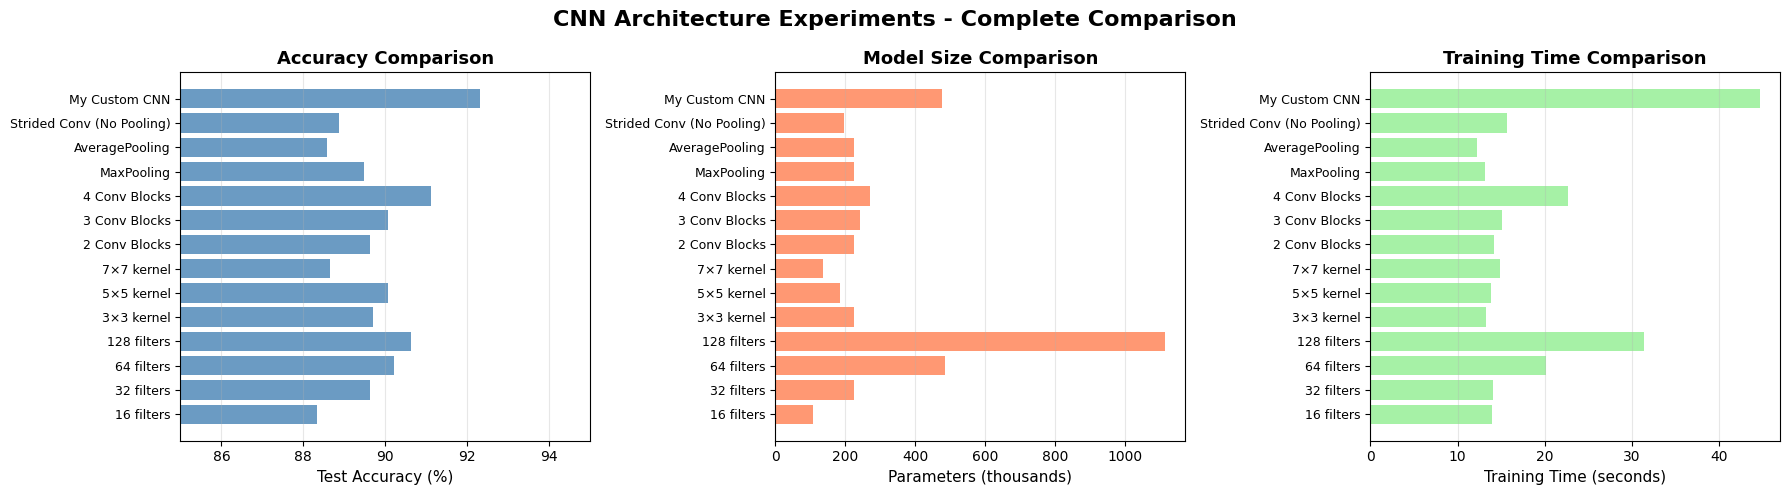

In [10]:
# Extract data for plotting
names = [r['name'] for r in results]
accuracies = [r['test_accuracy'] * 100 for r in results]
params = [r['parameters'] / 1000 for r in results]  # In thousands
times = [r['training_time'] for r in results]

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy comparison
axes[0].barh(range(len(names)), accuracies, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=9)
axes[0].set_xlabel('Test Accuracy (%)', fontsize=11)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlim([85, 95])
axes[0].grid(True, alpha=0.3, axis='x')

# Parameters comparison
axes[1].barh(range(len(names)), params, color='coral', alpha=0.8)
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=9)
axes[1].set_xlabel('Parameters (thousands)', fontsize=11)
axes[1].set_title('Model Size Comparison', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Training time comparison
axes[2].barh(range(len(names)), times, color='lightgreen', alpha=0.8)
axes[2].set_yticks(range(len(names)))
axes[2].set_yticklabels(names, fontsize=9)
axes[2].set_xlabel('Training Time (seconds)', fontsize=11)
axes[2].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('CNN Architecture Experiments - Complete Comparison',
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Accuracy vs Parameters Trade-off

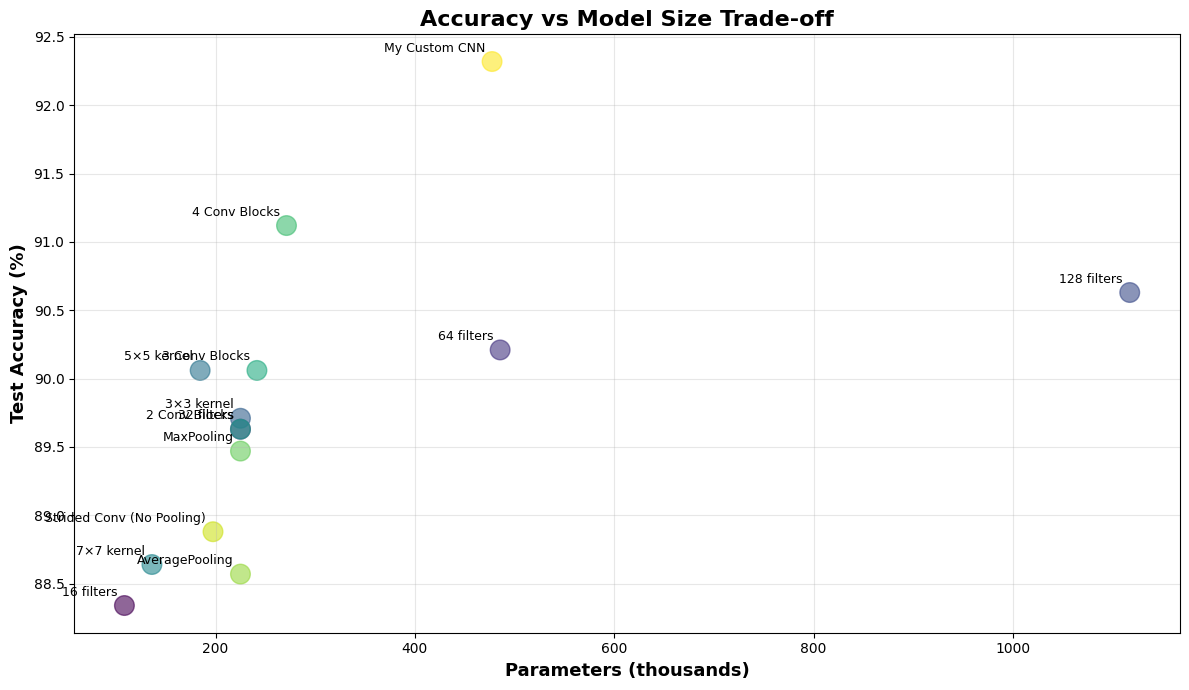


💡 Insight: The best models balance accuracy and efficiency!


In [11]:
# Scatter plot: Accuracy vs Parameters
plt.figure(figsize=(12, 7))
plt.scatter(params, accuracies, s=200, alpha=0.6, c=range(len(results)), cmap='viridis')

# Annotate points
for i, name in enumerate(names):
    plt.annotate(name, (params[i], accuracies[i]),
                fontsize=9, ha='right', va='bottom',
                xytext=(-5, 5), textcoords='offset points')

plt.xlabel('Parameters (thousands)', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
plt.title('Accuracy vs Model Size Trade-off', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Insight: The best models balance accuracy and efficiency!")

---

## 🎓 Final Reflection

### Answer these overall questions:

### ✍️ FINAL REFLECTION:

**1. What was the most surprising finding from your experiments?**

[Write your answer]

**2. If you were building a CNN for a production app (limited resources), which configuration would you choose and why?**

[Write your answer]

**3. What are 3 key principles you learned about CNN architecture design?**

1. [Write principle 1]
2. [Write principle 2]
3. [Write principle 3]

**4. What questions do you still have about CNNs?**

[Write your questions]

---

## 📤 Submission Checklist

Before submitting, ensure:

- [ ] All 5 experiments completed
- [ ] All reflection questions answered
- [ ] Custom architecture (Experiment 5) achieves >88% accuracy
- [ ] Results visualizations generated
- [ ] Final reflection completed
- [ ] Notebook runs without errors (Cell → Run All)
- [ ] Uploaded to Google Colab/Classroom

---

## 🏆 Grading Rubric (20 points)

| Component | Points |
|-----------|--------|
| Experiment 1 completed + reflections | 3 |
| Experiment 2 completed + reflections | 3 |
| Experiment 3 completed + reflections | 3 |
| Experiment 4 completed + reflections | 3 |
| Experiment 5 custom architecture | 4 |
| Final reflection quality | 2 |
| Code runs without errors | 2 |
| **Bonus: Accuracy >92%** | +2 |

---

**Great work! You've systematically explored CNN architectures! 🎉**

**Next class:** We'll learn about batch normalization, dropout, and data augmentation to push accuracy even higher!

---

*⏱️ Time to complete: ~2-3 hours*  
*💪 Difficulty: Intermediate*  
*🎓 Learning value: Very High*